In [49]:
#Required Libaries
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [50]:
#Creates an array of size n
def createArray(n):
    return list(np.random.randint(100, size = n))

def createTestData():
    testData = []
    for i in range(0, 100):
        testData.append(createArray(i))
    return testData

In [51]:
#Insert sort implementation
def InsertionSort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i-1
        #If the checkeed element is greater than the key then we move those array elements to one position ahead
        while j>=0 and key<arr[j]: 
            arr[j+1] = arr[j]
            j -= 1
        arr[j+1] = key
    return arr

def TimeInsertionSort(arr):
    start = time.perf_counter()
    InsertionSort(arr)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [ ]:
#Quick sort Implementation
def swap(arr, i, j):
    arr[i], arr[j] = arr[j], arr[i]

def partition(arr, low, high):
    # Choosing the piviot 
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] < pivot:
            i += 1
            swap(arr, i, j)
    swap(arr, i + 1, high)
    return i + 1

def QuickSort(arr, low, high):
    if low < high:
        pi = partition(arr, low, high)
        QuickSort(arr, low, pi - 1)
        QuickSort(arr, pi + 1, high)

def TimeQuickSort(arr):
    start = time.perf_counter()
    QuickSort(arr, 0, len(arr) -1)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1
 

In [53]:
def HybridSort(arr, k):
    if(len(arr) < k):
        InsertionSort(arr)
    else:
        QuickSort(arr, 0, len(arr) -1)

def TimeHybridSort(arr):
    start = time.perf_counter()
    HybridSort(arr, 25)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [54]:
def TestCorrectness(arr):
    buffer_array = arr
    buffer_array.sort()
    return arr == buffer_array

In [55]:
#Needs to make sure the size N is in the Y axis
def main():
    testData = createTestData()
    insertionData = []
    quickData = []
    testDataLength = []
    hybridData = []
    #Collecting data for the time it takes to perform quick sort and insertion sort on the arrays created of different sizes.
    for testArray in testData:
        testDataLength.append(len(testArray))
        #We pass copies of the array so that each algorithm deals with the original unsorted array
        quickData.append(TimeQuickSort(testArray.copy()))
        insertionData.append(TimeInsertionSort(testArray.copy()))
    #If there is a -1 in the data, that means that the data for insertion or quick sort failed to pass the correctness test
    if(-1 in insertionData or -1 in quickData):
        print("One of the arrays were not sorted correctly.")
        return 1
    fig = plt.figure()
    fig, ax = plt.subplots(layout = "constrained")
    testDataLength = np.array(testDataLength)
    a, b = np.polyfit(testDataLength, insertionData, 1)
    c, d = np.polyfit(testDataLength, quickData, 1)
    xintersection = (d-b)/(a-c)
    xintersection = int(xintersection)
    for testArray in testData:
        hybridData.append(TimeHybridSort(testArray.copy()))
    print(f"{a} {b} {c} {d}\nIntersection: {xintersection}")
    e, f = np.polyfit(testDataLength, hybridData, 1)
    #ax.scatter(testDataLength, insertionData)
    #ax.scatter(testDataLength, quickData)
    ax.plot(testDataLength, a*testDataLength+b, label = "Insertion Sort")
    ax.plot(testDataLength, c*testDataLength+d, label = "Quick Sort")
    ax.plot(testDataLength, e*testDataLength+f, label = "Hybrid Sort")
    #Intersection lies between ~25.3-25.9

    #Naming the graph and axes of the graph
    ax.set_title("Time to sort vs Size of array")
    ax.set_ylabel("Time")
    ax.set_xlabel("Size of array")
    ax.legend()
    print(insertionData)
    print(quickData)
    print(hybridData)

3.6078602174912264e-06 -5.94860807321689e-05 1.7480126280761462e-06 -1.0323624736352803e-05
Intersection: 26
[3.999986802227795e-06, 8.999923011288047e-07, 2.7000060072168708e-06, 2.5000044843181968e-06, 3.899986040778458e-06, 3.3999967854470015e-06, 3.6999990697950125e-06, 4.2000028770416975e-06, 4.8000074457377195e-06, 6.200003554113209e-06, 4.599991370923817e-06, 6.000002031214535e-06, 7.700000423938036e-06, 6.999995093792677e-06, 1.0400006431154907e-05, 1.0799994925037026e-05, 1.1500000255182385e-05, 1.4899997040629387e-05, 1.5199999324977398e-05, 1.5199999324977398e-05, 1.4899997040629387e-05, 1.6599995433352888e-05, 1.8600010662339628e-05, 2.5500004994682968e-05, 2.7799993404187262e-05, 2.8800001018680632e-05, 3.360000846441835e-05, 3.0199997127056122e-05, 2.8700000257231295e-05, 3.139999171253294e-05, 3.1499992473982275e-05, 3.6900004488416016e-05, 3.640000068116933e-05, 3.9699996705166996e-05, 4.959999932907522e-05, 5.250000685919076e-05, 4.7900000936351717e-05, 4.8299989430233

<Figure size 640x480 with 0 Axes>

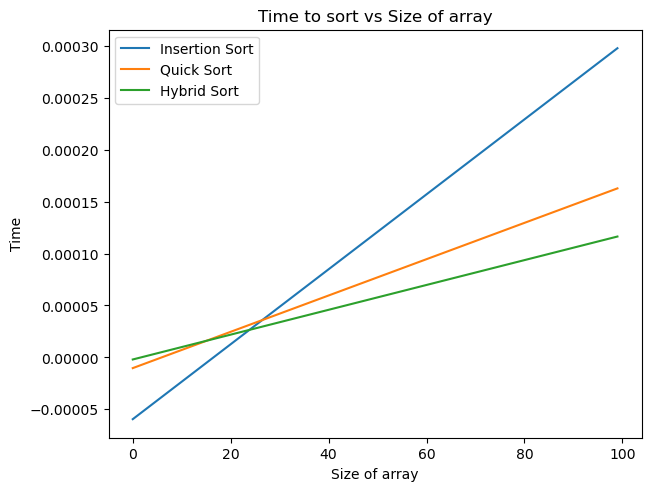

In [56]:
main()